In [1]:
#Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Regression
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [3]:
# Load dataset
df = pd.read_csv("Day18_19_student_habits_performance.csv")

# Display first 5 rows
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
#Shape of dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 16


In [7]:
#Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [9]:
#Statistical summary
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [11]:
# Numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']


In [13]:
# Categorical columns

categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [15]:
# Check missing values
missing_values = df.isnull().sum()
print(missing_values)

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [17]:
# Display only columns containing missing values
missing_values[missing_values > 0]

parental_education_level    91
dtype: int64

In [19]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


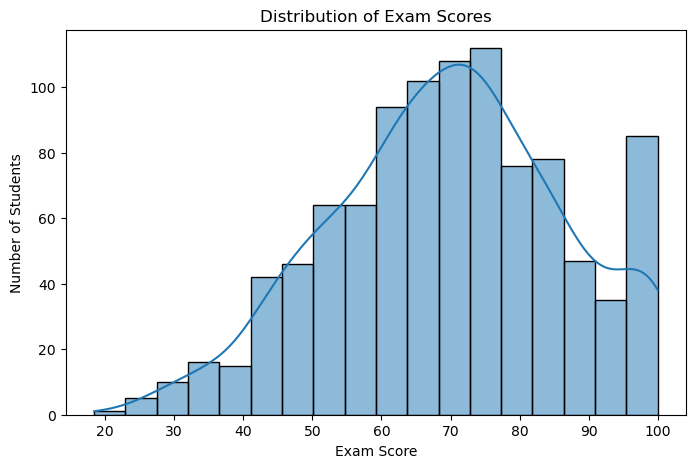

In [21]:
#Exam Score Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df['exam_score'], kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

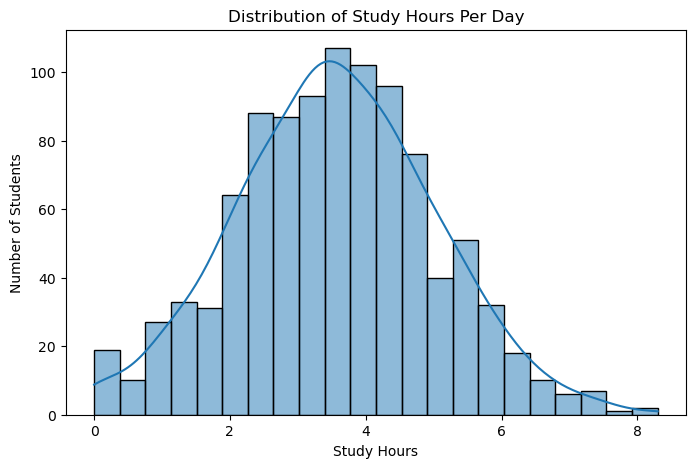

In [23]:
#Study Hours
plt.figure(figsize=(8, 5))

sns.histplot(df['study_hours_per_day'], kde=True)

plt.title("Distribution of Study Hours Per Day")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.show()

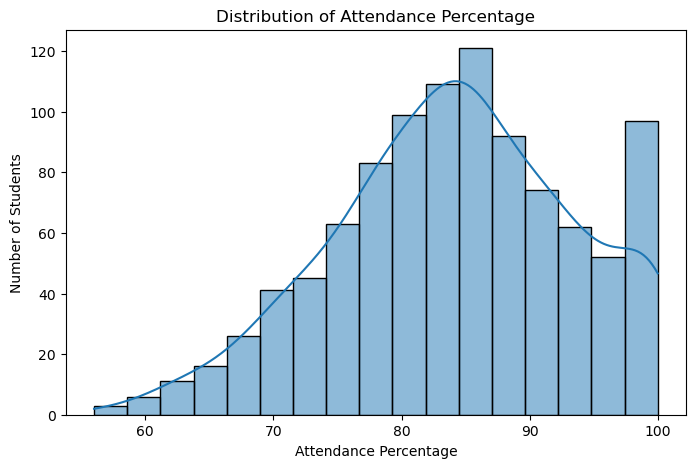

In [25]:
#Attendance
plt.figure(figsize=(8, 5))

sns.histplot(df['attendance_percentage'], kde=True)

plt.title("Distribution of Attendance Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.show()

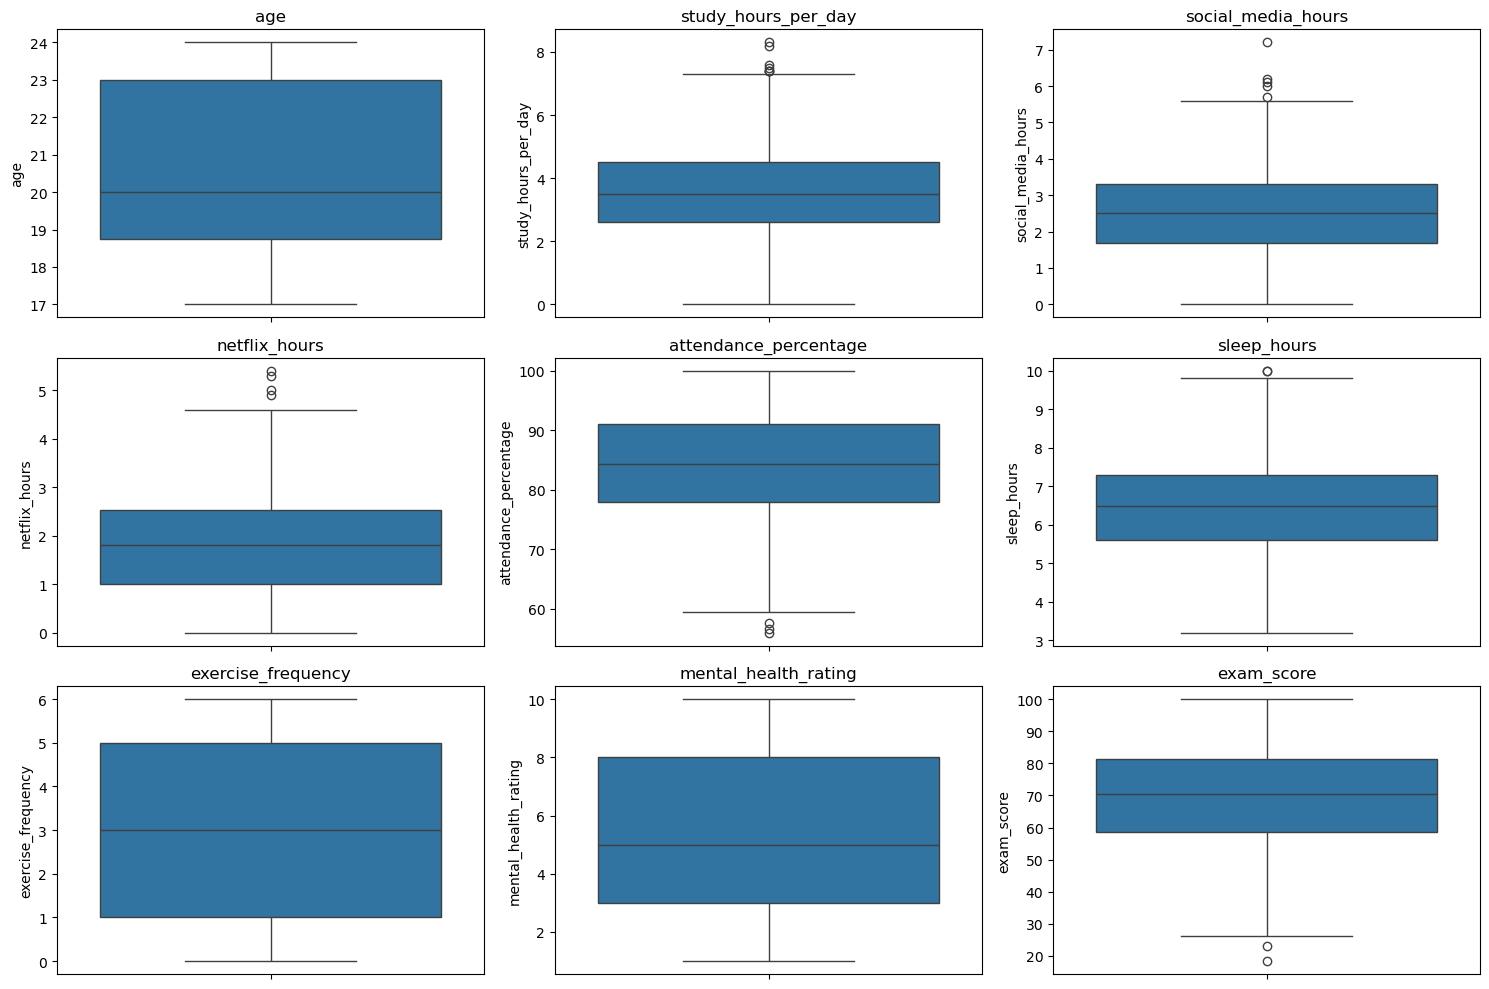

In [27]:
# Boxplots for numerical variables

plt.figure(figsize=(15, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

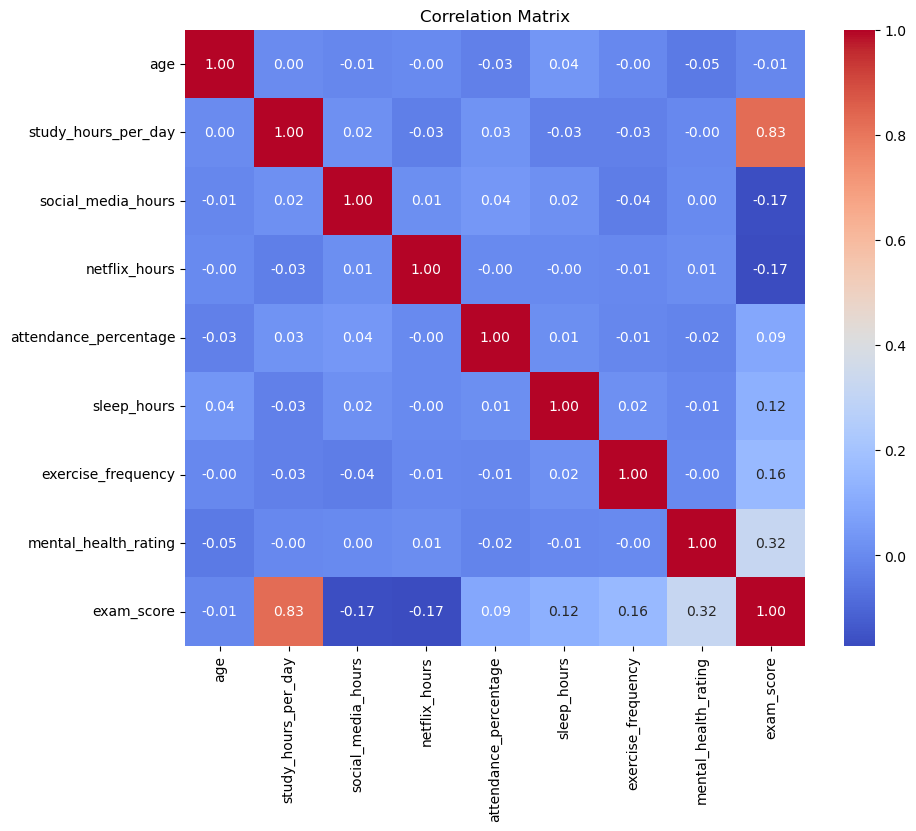

In [29]:
# Correlation Analysis
# Correlation matrix

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [31]:
# Correlation of numerical variables with exam_score
exam_score_corr = df[numerical_columns].corr()['exam_score'].sort_values(
    ascending=False
)

print(exam_score_corr)

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


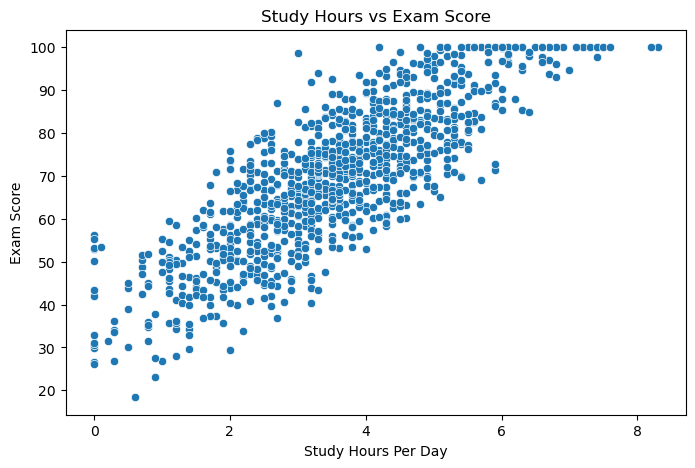

In [35]:
#Relation between study hours and Exam Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='study_hours_per_day',
    y='exam_score'
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Exam Score")
plt.show()

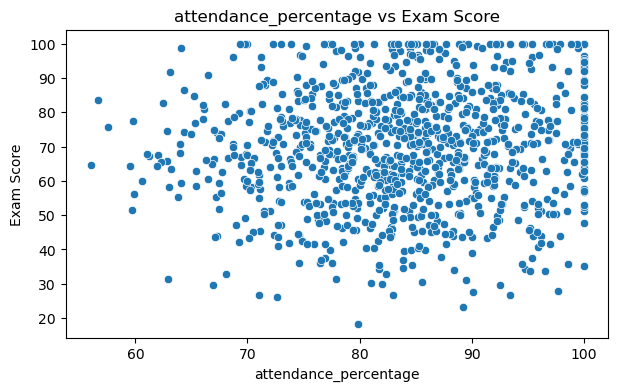

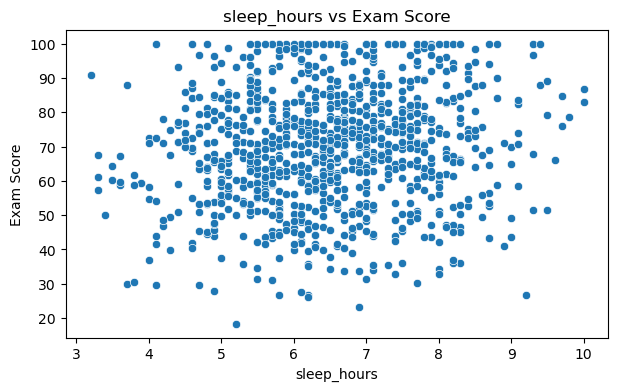

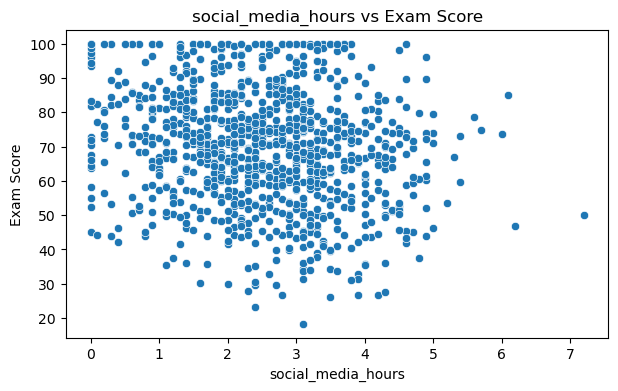

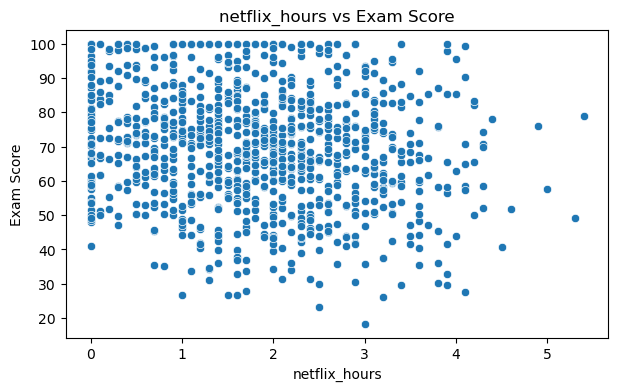

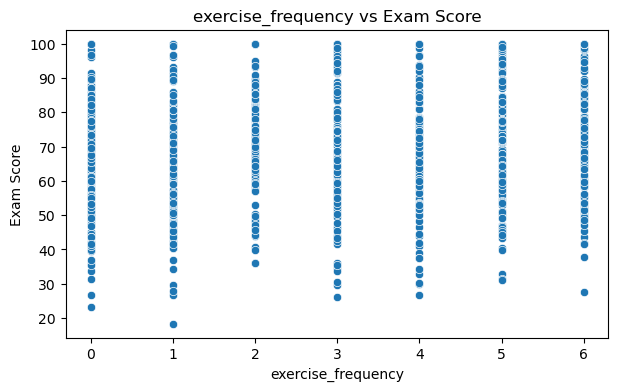

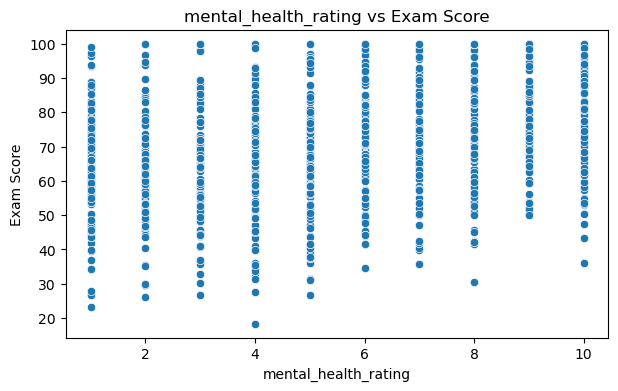

In [37]:
#Relation between other important variables and Exam Scores
important_features = [
    'attendance_percentage',
    'sleep_hours',
    'social_media_hours',
    'netflix_hours',
    'exercise_frequency',
    'mental_health_rating'
]

for column in important_features:
    
    plt.figure(figsize=(7, 4))
    
    sns.scatterplot(
        data=df,
        x=column,
        y='exam_score'
    )
    
    plt.title(f"{column} vs Exam Score")
    plt.xlabel(column)
    plt.ylabel("Exam Score")
    plt.show()

In [39]:
# Categorical Variables Analysis
# Examine categorical variables

categorical_analysis_columns = [
    'gender',
    'part_time_job',
    'diet_quality',
    'parental_education_level',
    'internet_quality',
    'extracurricular_participation'
]

for column in categorical_analysis_columns:
    
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 gender
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

 part_time_job
part_time_job
No     785
Yes    215
Name: count, dtype: int64

 diet_quality
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

 parental_education_level
parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64

 internet_quality
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

 extracurricular_participation
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64


In [41]:
# Average Exam Score by Categorical Variables
for column in categorical_analysis_columns:
    
    print("\nAverage Exam Score by", column)
    
    print(
        df.groupby(column, dropna=False)['exam_score']
        .mean()
        .sort_values(ascending=False)
    )


Average Exam Score by gender
gender
Other     70.647619
Female    69.741372
Male      69.368344
Name: exam_score, dtype: float64

Average Exam Score by part_time_job
part_time_job
No     69.836561
Yes    68.743256
Name: exam_score, dtype: float64

Average Exam Score by diet_quality
diet_quality
Fair    70.428833
Good    69.366402
Poor    68.127568
Name: exam_score, dtype: float64

Average Exam Score by parental_education_level
parental_education_level
Bachelor       70.272571
NaN            70.034066
High School    69.547194
Master         68.086826
Name: exam_score, dtype: float64

Average Exam Score by internet_quality
internet_quality
Average    70.643990
Poor       69.717284
Good       68.647651
Name: exam_score, dtype: float64

Average Exam Score by extracurricular_participation
extracurricular_participation
Yes    69.623270
No     69.591349
Name: exam_score, dtype: float64


In [43]:
# Data Preparation for ML
# Define features and target

features = [
    'age',
    'gender',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'part_time_job',
    'attendance_percentage',
    'sleep_hours',
    'diet_quality',
    'exercise_frequency',
    'parental_education_level',
    'internet_quality',
    'mental_health_rating',
    'extracurricular_participation'
]

X = df[features]

y = df['exam_score']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 14)
Target shape: (1000,)


In [45]:
#Identify Numerical and Categorical Features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Categorical Features:
['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [47]:
# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [49]:
#Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 14)
Testing data: (200, 14)


In [51]:
#Train Linear Regression Model
linear_regression_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Train model
linear_regression_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'study_hours_per_day',
                                                   'social_media_hours',
                                                   'netflix_hours',
                                                   'attendance_percentage',
                                                   'sleep_hours',
                                                   'exercise_frequency',
                                                   'mental_health_rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', LinearRegression())])

In [53]:
# Predictions on training data
y_train_pred = linear_regression_model.predict(X_train)

# Predictions on testing data
y_test_pred = linear_regression_model.predict(X_test)

In [55]:
# Training metrics

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)


# Testing metrics

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)


print("TRAINING PERFORMANCE")
print("--------------------")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nTESTING PERFORMANCE")
print("-------------------")
print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

TRAINING PERFORMANCE
--------------------
MAE : 4.214166226437829
MSE : 28.566057662268452
RMSE: 5.344722412087315
R²  : 0.9021075354141658

TESTING PERFORMANCE
-------------------
MAE : 4.19234311037991
MSE : 26.532535044099465
RMSE: 5.150974183986896
R²  : 0.8965307156715966


The model explains approximately 89.7% of the variation in exam scores on unseen test data.  
The RMSE is around 5.15 marks, meaning that the model's predictions typically differ from the actual exam score by roughly 5 marks.

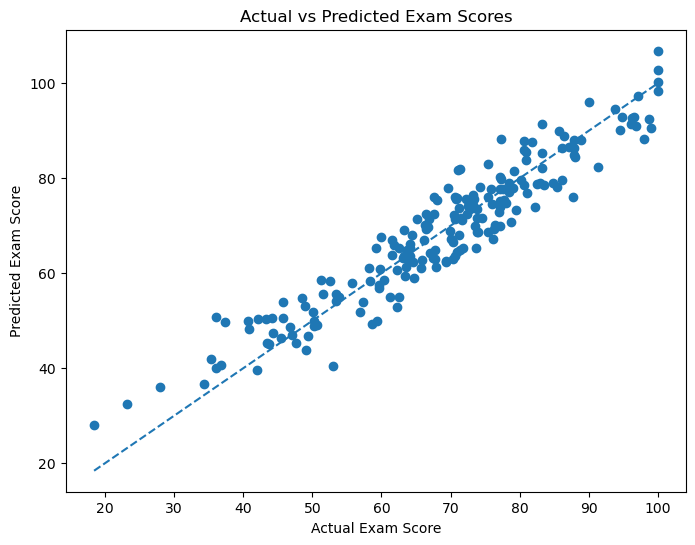

In [59]:
#Actual vs Predicted Exam Scores
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [61]:
# Create Pass/Fail target
df['pass_fail'] = np.where(
    df['exam_score'] >= 50,
    1,
    0
)

df[['exam_score', 'pass_fail']].head(10)

,exam_score,pass_fail
0,56.2,1
1,100.0,1
2,34.3,0
3,26.8,0
4,66.4,1
5,100.0,1
6,89.8,1
7,72.6,1
8,78.9,1
9,100.0,1


In [63]:
df['result'] = np.where(
    df['exam_score'] >= 50,
    'Pass',
    'Fail'
)

df[['exam_score', 'result']].head(10)

,exam_score,result
0,56.2,Pass
1,100.0,Pass
2,34.3,Fail
3,26.8,Fail
4,66.4,Pass
5,100.0,Pass
6,89.8,Pass
7,72.6,Pass
8,78.9,Pass
9,100.0,Pass


result
Pass    869
Fail    131
Name: count, dtype: int64


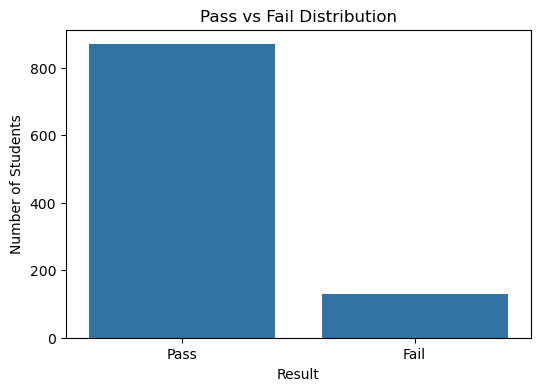

In [65]:
print(df['result'].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='result')

plt.title("Pass vs Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

In [67]:
# Features remain the same
X_classification = df[features]

# Classification target
y_classification = df['pass_fail']

In [69]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Training data:", X_train_class.shape)
print("Testing data:", X_test_class.shape)

Training data: (800, 14)
Testing data: (200, 14)


In [71]:
# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

# Train model

logistic_model.fit(
    X_train_class,
    y_train_class
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'study_hours_per_day',
                                                   'social_media_hours',
                                                   'netflix_hours',
                                                   'attendance_percentage',
                                                   'sleep_hours',
                                                   'exercise_frequency',
                                                   'mental_health_rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [73]:
# Training predictions
y_train_class_pred = logistic_model.predict(X_train_class)

# Testing predictions
y_test_class_pred = logistic_model.predict(X_test_class)

In [75]:
# Confusion matrix
cm = confusion_matrix(
    y_test_class,
    y_test_class_pred
)

print(cm)

[[ 21   5]
 [  4 170]]


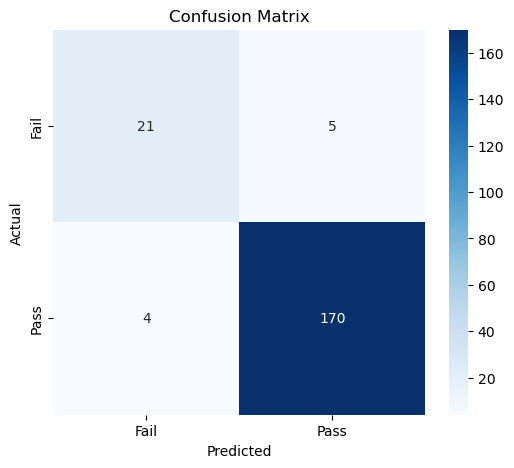

In [77]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fail', 'Pass'],
    yticklabels=['Fail', 'Pass']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

- 21 students correctly predicted as Fail
- 170 students correctly predicted as Pass
- 5 Fail students incorrectly predicted as Pass
- 4 Pass students incorrectly predicted as Fail

In [80]:
# Calculate testing metrics

accuracy = accuracy_score(
    y_test_class,
    y_test_class_pred
)

precision = precision_score(
    y_test_class,
    y_test_class_pred
)

recall = recall_score(
    y_test_class,
    y_test_class_pred
)

f1 = f1_score(
    y_test_class,
    y_test_class_pred
)

print("Classification Test Performance")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Classification Test Performance
--------------------------------
Accuracy : 0.955
Precision: 0.9714285714285714
Recall   : 0.9770114942528736
F1 Score : 0.9742120343839542


In [82]:
# Training metrics

train_accuracy = accuracy_score(
    y_train_class,
    y_train_class_pred
)

train_precision = precision_score(
    y_train_class,
    y_train_class_pred
)

train_recall = recall_score(
    y_train_class,
    y_train_class_pred
)

train_f1 = f1_score(
    y_train_class,
    y_train_class_pred
)


# Testing metrics

test_accuracy = accuracy_score(
    y_test_class,
    y_test_class_pred
)

test_precision = precision_score(
    y_test_class,
    y_test_class_pred
)

test_recall = recall_score(
    y_test_class,
    y_test_class_pred
)

test_f1 = f1_score(
    y_test_class,
    y_test_class_pred
)


comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Training': [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ],
    'Testing': [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

comparison

,Metric,Training,Testing
0,Accuracy,0.957500,0.955000
1,Precision,0.970128,0.971429
2,Recall,0.981295,0.977011
3,F1 Score,0.975680,0.974212


In [84]:
#Check for overfitting and underfitting
print("Regression R²")
print("Training:", train_r2)
print("Testing :", test_r2)

print("\nClassification Accuracy")
print("Training:", train_accuracy)
print("Testing :", test_accuracy)

Regression R²
Training: 0.9021075354141658
Testing : 0.8965307156715966

Classification Accuracy
Training: 0.9575
Testing : 0.955


## Conclusion – Five Key Insights

1. **Study hours are the strongest factor associated with exam performance.**
   The correlation between `study_hours_per_day` and `exam_score` is approximately 0.825, showing a strong positive relationship. Students who spend more time studying generally achieve higher exam scores.

2. **Mental health is positively associated with academic performance.**
   `mental_health_rating` has a positive correlation of approximately 0.322 with exam score. This suggests that students with better mental well-being tend to perform better academically.

3. **Excessive entertainment and social-media usage may be associated with lower scores.**
   `social_media_hours` and `netflix_hours` have negative correlations with exam score of approximately -0.167 and -0.172 respectively. This indicates that higher amounts of time spent on these activities are generally associated with lower academic performance.

4. **The regression model performs well on unseen students.**
   The Linear Regression model achieved a testing R² of approximately 0.897 and an RMSE of approximately 5.15 marks. This means the model explains about 89.7% of the variation in exam scores while making predictions with an average error of roughly five marks.

5. **The classification model is highly effective at identifying Pass/Fail outcomes.**
   Using 50 marks as the passing threshold, Logistic Regression achieved approximately 95.5% testing accuracy and an F1-score of approximately 0.974. The similarity between training and testing performance indicates good generalization without significant overfitting.
